# PulseChain: HIV/ARV Shipment Delay Prediction (Initial Model Notebook)
**Goal:** predict whether a shipment will arrive late (`target_late = 1`) using only information known when it is ordered.
**Data:** PEPFAR/USAID SCMS Delivery History, filtered to 7 East African countries (2,317 shipments, 2006-2015).
**Models:** Logistic Regression (baseline) vs LightGBM, with SHAP explanations.

## 0. Colab setup
Run this cell, then upload `SCMS_Delivery_History_Dataset_20150929.csv` when prompted.

In [3]:
!pip install -q shap lightgbm
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)
from google.colab import files
uploaded = files.upload()

Saving SCMS_Delivery_History_Dataset_20150929 2.csv to SCMS_Delivery_History_Dataset_20150929 2 (1).csv


## 1. Load data and filter to the 7 East African countries

In [4]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
DATA = "SCMS_Delivery_History_Dataset_20150929 2.csv"
df = pd.read_csv(DATA, encoding="latin-1")
print("All rows:", df.shape)
COUNTRIES = ["Rwanda","Uganda","Tanzania","Kenya","Burundi","South Sudan","Ethiopia"]
df = df[df["Country"].isin(COUNTRIES)].copy()
print("East Africa rows:", df.shape)
df["Country"].value_counts()

All rows: (10324, 33)
East Africa rows: (2317, 33)


,count
Country,
Uganda,779
Tanzania,519
Rwanda,430
Ethiopia,216
South Sudan,164
Kenya,111
Burundi,98


## 2. Data engineering: dates, target, numeric cleaning
Text such as `Freight Included in Commodity Cost` is not a number, so it becomes missing (NaN) rather than being guessed.

In [5]:
for c in ["PO Sent to Vendor Date","Scheduled Delivery Date","Delivered to Client Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
df["delay_days"] = (df["Delivered to Client Date"] - df["Scheduled Delivery Date"]).dt.days
df["target_late"] = (df["delay_days"] > 0).astype(int)
df["weight_kg"] = pd.to_numeric(df["Weight (Kilograms)"], errors="coerce")
df["freight_cost_usd"] = pd.to_numeric(df["Freight Cost (USD)"], errors="coerce")
df["planned_lead_time_days"] = (df["Scheduled Delivery Date"] - df["PO Sent to Vendor Date"]).dt.days
df["year"] = df["Scheduled Delivery Date"].dt.year
print(df["target_late"].value_counts())
print("Late share: %.1f%%" % (100*df["target_late"].mean()))
df[["weight_kg","freight_cost_usd","planned_lead_time_days"]].isna().mean().round(3)

target_late
0    2031
1     286
Name: count, dtype: int64
Late share: 12.3%


,0
weight_kg,0.257
freight_cost_usd,0.265
planned_lead_time_days,0.586


## 3. Data visualisation

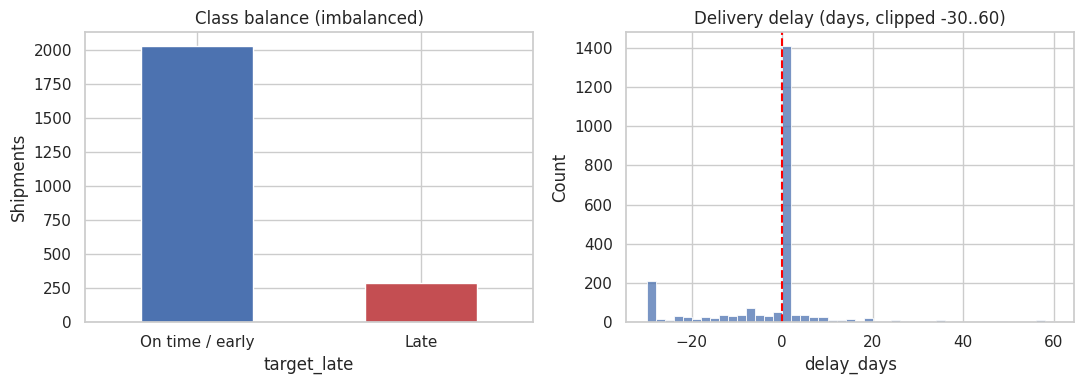

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
df["target_late"].map({0:"On time / early",1:"Late"}).value_counts().plot.bar(ax=ax[0], color=["#4C72B0","#C44E52"])
ax[0].set_title("Class balance (imbalanced)"); ax[0].set_ylabel("Shipments"); ax[0].tick_params(axis="x", rotation=0)
sns.histplot(df["delay_days"].clip(-30,60), bins=45, ax=ax[1], color="#4C72B0")
ax[1].axvline(0, color="red", ls="--"); ax[1].set_title("Delivery delay (days, clipped -30..60)")
plt.tight_layout(); plt.savefig("figures/01_class_balance_delay.png", dpi=150); plt.show()

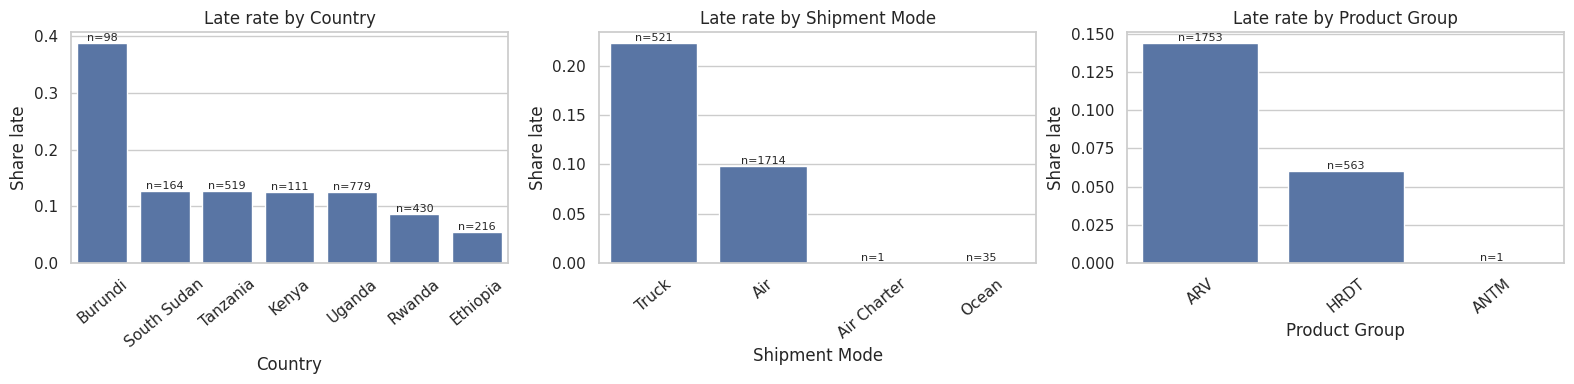

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
for a, col in zip(ax, ["Country","Shipment Mode","Product Group"]):
    r = df.groupby(col)["target_late"].agg(["mean","count"]).sort_values("mean", ascending=False)
    sns.barplot(x=r.index, y=r["mean"], ax=a, color="#4C72B0")
    a.set_title("Late rate by "+col); a.set_ylabel("Share late"); a.tick_params(axis="x", rotation=40)
    for i,(m,n) in enumerate(zip(r["mean"], r["count"])): a.text(i, m, "n=%d"%n, ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig("figures/02_late_rate_by_group.png", dpi=150); plt.show()

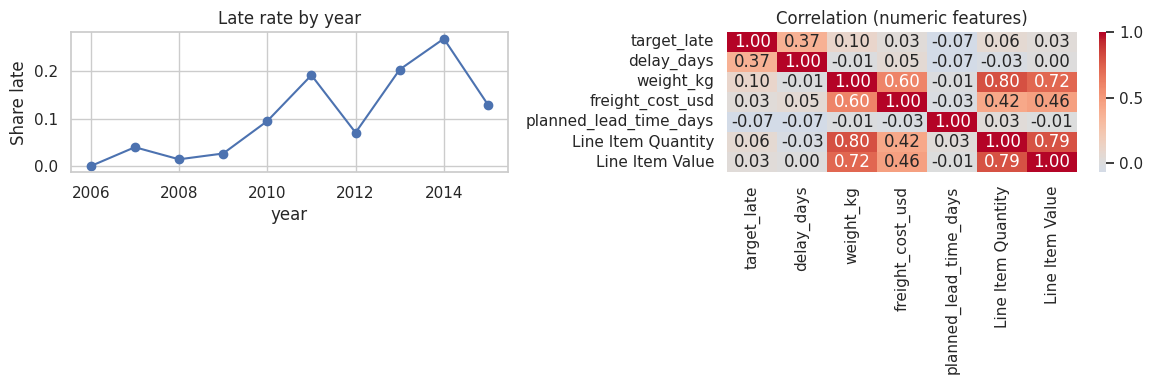

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
df.groupby("year")["target_late"].mean().plot(marker="o", ax=ax[0]); ax[0].set_title("Late rate by year"); ax[0].set_ylabel("Share late")
num = df[["target_late","delay_days","weight_kg","freight_cost_usd","planned_lead_time_days","Line Item Quantity","Line Item Value"]]
sns.heatmap(num.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1]); ax[1].set_title("Correlation (numeric features)")
plt.tight_layout(); plt.savefig("figures/03_year_correlation.png", dpi=150); plt.show()

## 4. Leakage-safe history features
For each shipment we use only **earlier** shipments from the same vendor/country (`shift(1)` before the running mean), so the model never sees the future. `delay_days` is **not** used as a feature because it is the answer.

In [9]:
df = df.sort_values("Scheduled Delivery Date").reset_index(drop=True)
def past_mean(group_col):
    prior = df.groupby(group_col)["target_late"].transform(lambda s: s.shift(1).expanding().mean())
    return prior.fillna(df["target_late"].expanding().mean().shift(1)).fillna(df["target_late"].mean())
df["vendor_past_late_rate"]  = past_mean("Vendor")
df["country_past_late_rate"] = past_mean("Country")
df["vendor_shipment_count_so_far"] = df.groupby("Vendor").cumcount()
FEATURES_NUM = ["planned_lead_time_days","weight_kg","freight_cost_usd","Line Item Quantity","Line Item Value",
                "vendor_past_late_rate","country_past_late_rate","vendor_shipment_count_so_far"]
FEATURES_CAT = ["Country","Shipment Mode","Vendor INCO Term","Fulfill Via","Product Group"]
X = df[FEATURES_NUM + FEATURES_CAT]; y = df["target_late"]
X.head()

,planned_lead_time_days,weight_kg,freight_cost_usd,Line Item Quantity,Line Item Value,vendor_past_late_rate,country_past_late_rate,vendor_shipment_count_so_far,Country,Shipment Mode,Vendor INCO Term,Fulfill Via,Product Group
0,NaN,1478.0,6212.41,16667,60834.55,0.123435,0.123435,0,Tanzania,Air,EXW,Direct Drop,ARV
1,NaN,1172.0,5595.44,5080,55880.00,0.000000,0.000000,1,Uganda,Air,EXW,Direct Drop,ARV
2,NaN,NaN,NaN,6349,12380.55,0.000000,0.000000,2,Uganda,Air,EXW,Direct Drop,ARV
3,NaN,NaN,NaN,5080,85090.00,0.000000,0.000000,3,Uganda,Air,EXW,Direct Drop,ARV
4,NaN,369.0,2623.49,6349,21269.15,0.000000,0.000000,0,Uganda,Air,EXW,Direct Drop,ARV


## 5. Time-based train/test split
Oldest 80% of shipments train the model; the newest 20% test it, mimicking real use (predict the future from the past).

In [10]:
split = int(len(df)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print("Train:", X_train.shape, "late rate %.3f" % y_train.mean(), "| up to", df["Scheduled Delivery Date"].iloc[split-1].date())
print("Test: ", X_test.shape,  "late rate %.3f" % y_test.mean(),  "| from", df["Scheduled Delivery Date"].iloc[split].date())

Train: (1853, 13) late rate 0.110 | up to 2014-01-31
Test:  (464, 13) late rate 0.177 | from 2014-01-31


## 6. Model architecture
This is a tabular classification problem, so there are **no neural-network layers or activation functions**.
- **Preprocessing (both models):** numeric columns -> median imputation (+ standard scaling for LR); categorical columns -> most-frequent imputation + one-hot encoding.
- **Baseline: Logistic Regression** - one linear layer + sigmoid: P(late) = 1 / (1 + e^-(w.x + b)). Optimised with L-BFGS minimising log-loss; `class_weight="balanced"` handles the ~12% late minority.
- **LightGBM** - gradient-boosted decision trees (leaf-wise growth). Each new tree fits the errors of the previous ones; trained by gradient descent on log-loss with learning rate 0.05; `scale_pos_weight` handles imbalance.
- **Metric focus:** Recall (a missed delay is costly), tracked with Precision, F1, F2 and ROC-AUC.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, fbeta_score,
                             roc_auc_score, confusion_matrix, classification_report)
import lightgbm as lgb
def make_pre(scale):
    num_steps = [("imp", SimpleImputer(strategy="median"))] + ([("sc", StandardScaler())] if scale else [])
    return ColumnTransformer([
        ("num", Pipeline(num_steps), FEATURES_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), FEATURES_CAT)])
lr = Pipeline([("pre", make_pre(True)),
               ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))])
pos_weight = (y_train==0).sum() / (y_train==1).sum()
lgbm = Pipeline([("pre", make_pre(False)),
                 ("clf", lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                         min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=pos_weight, random_state=42, verbose=-1))])

## 7. Train and evaluate (initial performance metrics)

In [12]:
def evaluate(name, model, thr=0.5):
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:,1]; pred = (p >= thr).astype(int)
    return {"Model":name, "Precision":precision_score(y_test,pred,zero_division=0), "Recall":recall_score(y_test,pred),
            "F1":f1_score(y_test,pred), "F2 (recall-weighted)":fbeta_score(y_test,pred,beta=2),
            "ROC-AUC":roc_auc_score(y_test,p)}, pred, p
res_lr,   pred_lr,   p_lr   = evaluate("Logistic Regression (baseline)", lr)
res_lgbm, pred_lgbm, p_lgbm = evaluate("LightGBM", lgbm)
results = pd.DataFrame([res_lr, res_lgbm]).set_index("Model").round(3)
results

,Precision,Recall,F1,F2 (recall-weighted),ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.272,0.841,0.411,0.593,0.653
LightGBM,0.283,0.817,0.420,0.593,0.687


              precision    recall  f1-score   support

     On time       0.93      0.55      0.70       382
        Late       0.28      0.82      0.42        82

    accuracy                           0.60       464
   macro avg       0.61      0.69      0.56       464
weighted avg       0.82      0.60      0.65       464



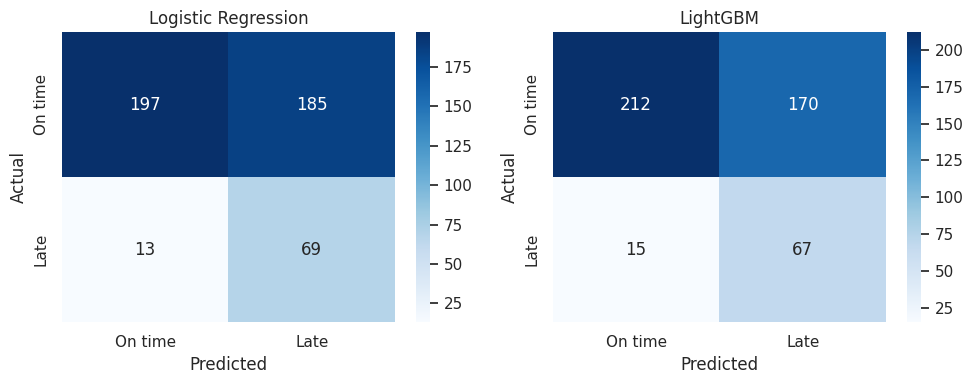

In [13]:
print(classification_report(y_test, pred_lgbm, target_names=["On time","Late"]))
fig, ax = plt.subplots(1, 2, figsize=(10,4))
for a, (n, pr) in zip(ax, [("Logistic Regression", pred_lr), ("LightGBM", pred_lgbm)]):
    sns.heatmap(confusion_matrix(y_test, pr), annot=True, fmt="d", cmap="Blues", ax=a,
                xticklabels=["On time","Late"], yticklabels=["On time","Late"])
    a.set_title(n); a.set_xlabel("Predicted"); a.set_ylabel("Actual")
plt.tight_layout(); plt.savefig("figures/04_confusion_matrices.png", dpi=150); plt.show()

## 8. Explainability with SHAP (why is a shipment flagged?)

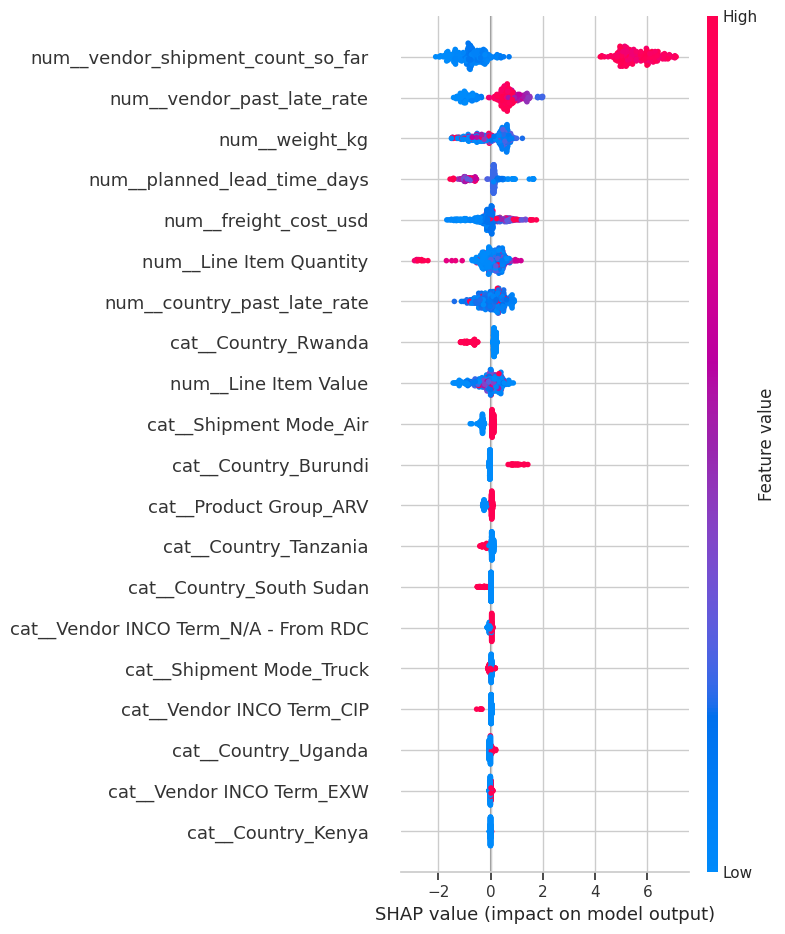

In [14]:
import shap
Xt = lgbm.named_steps["pre"].transform(X_test)
names = lgbm.named_steps["pre"].get_feature_names_out()
explainer = shap.TreeExplainer(lgbm.named_steps["clf"])
sv = explainer.shap_values(Xt)
sv = sv[1] if isinstance(sv, list) else sv
shap.summary_plot(sv, Xt, feature_names=names, show=False)
plt.tight_layout(); plt.savefig("figures/05_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Save the trained model (used later by the Streamlit app)

In [15]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(lgbm, "models/lgbm_pipeline.joblib")
joblib.dump(lr, "models/logreg_pipeline.joblib")
results.to_csv("models/initial_metrics.csv"); print("Saved.")

Saved.


## 10. Notes and limitations
- Data is 2006-2015 (historical); this is a proof of concept.
- Only ~286 late shipments in total, so metrics on the small test set are noisy.
- Next: tune the decision threshold for higher Recall, cross-validate, then connect to the Streamlit reporting app.